# MWE 48 - Two-dimensional FEM manufactured solutions

This experiment verifies the finite-element Brinkman formulations in `voids`
against a divergence-free exact solution on the unit square. The body force is
manufactured automatically from

\[
-\nu\Delta\mathbf{u}+\gamma\mathbf{u}+\nabla p=\mathbf{f},
\qquad \nabla\cdot\mathbf{u}=0.
\]

Success means that the last mesh pair attains the nominal smooth-solution
rates within the documented tolerance. The default viscosity is deliberately
moderate so the quick mesh sequence resolves the exponential boundary layer.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import NullLocator

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.examples.mms import (
    available_mms_methods,
    boundary_layer_case_2d,
    run_mms_convergence,
)
from voids.fem.singlephase import FEniCSSolverOptions

plt.ioff()

## Reproducible configuration

Set `use_reference_boundary_layer=True` to reproduce the sharper
\(\nu=10^{-2}\) case. That case needs the finer sequence through \(128^2\)
before velocity rates are asymptotic.

In [2]:
use_reference_boundary_layer = False
if use_reference_boundary_layer:
    viscosity = 1.0e-2
    resolutions = (16, 32, 64, 128)
else:
    viscosity = 1.0e-1
    resolutions = (8, 16, 32)

reaction = 1.0
methods = available_mms_methods()
absolute_rate_tolerance = 0.35
solver_options = FEniCSSolverOptions.superlu_direct()

case = boundary_layer_case_2d(
    viscosity=viscosity,
    reaction=reaction,
)

## Run all shipped FEM formulations

`P1/DG0` and `P1/DG1` use the reaction-diffusion pressure-jump coefficient
in 2D. Taylor-Hood uses the unstabilized `P2/P1` mixed form.

In [3]:
studies = {}
for method in methods:
    print(f"Running {method} on {resolutions}")
    studies[method] = run_mms_convergence(
        case,
        method=method,
        resolutions=resolutions,
        options=solver_options,
        keep_solution=False,
    )

rows = []
for method, study in studies.items():
    rows.extend({"method": method, **row} for row in study.as_dicts())
results = pd.DataFrame(rows)
display(results)

Running taylor_hood on (8, 16, 32)


Running usfem_p1dg0 on (8, 16, 32)
Running usfem_p1dg1 on (8, 16, 32)


,method,resolution,h,num_cells,num_dofs,solve_seconds,velocity_l2_error,velocity_h1_error,pressure_l2_error,divergence_l2,velocity_l2_rate,velocity_h1_rate,pressure_l2_rate,divergence_l2_rate
0,taylor_hood,8,0.12500,128,659,0.005076,0.003197,0.167993,0.000554,0.007869,NaN,NaN,NaN,NaN
1,taylor_hood,16,0.06250,512,2467,0.012860,0.000432,0.044930,0.000054,0.001420,2.888987,1.902658,3.364543,2.470122
2,taylor_hood,32,0.03125,2048,9539,0.097946,0.000055,0.011438,0.000005,0.000213,2.969689,1.973842,3.523841,2.738867
3,usfem_p1dg0,8,0.12500,128,290,0.001661,0.042700,1.063999,0.038736,0.045396,NaN,NaN,NaN,NaN
4,usfem_p1dg0,16,0.06250,512,1090,0.007220,0.011368,0.560228,0.016409,0.015803,1.909266,0.925411,1.239155,1.522382
5,usfem_p1dg0,32,0.03125,2048,4226,0.048745,0.002890,0.283993,0.007705,0.005484,1.975634,0.980159,1.090636,1.526894
6,usfem_p1dg1,8,0.12500,128,546,0.003301,0.050620,1.074853,0.084398,0.089571,NaN,NaN,NaN,NaN
7,usfem_p1dg1,16,0.06250,512,2114,0.021519,0.013751,0.563501,0.033412,0.037778,1.880164,0.931648,1.336860,1.245472
8,usfem_p1dg1,32,0.03125,2048,8322,0.207155,0.003545,0.284800,0.013837,0.014557,1.955826,0.984470,1.271812,1.375850


## Check the finest-pair rates

The assertion is intentionally one-sided: an observed rate must not fall more
than `absolute_rate_tolerance` below the nominal rate. Superconvergent
pre-asymptotic slopes are not rejected.

In [4]:
rate_rows = []
for method, study in studies.items():
    study.assert_expected_rates(
        absolute_tolerance=absolute_rate_tolerance,
    )
    rate_rows.append(
        {
            "method": method,
            **{f"observed_{name}": value for name, value in study.last_rates.items()},
            **{
                f"nominal_{name}": value
                for name, value in study.expected_rates.as_dict().items()
            },
        }
    )
rate_table = pd.DataFrame(rate_rows)
display(rate_table)

,method,observed_velocity_l2,observed_velocity_h1,observed_pressure_l2,observed_divergence_l2,nominal_velocity_l2,nominal_velocity_h1,nominal_pressure_l2
0,taylor_hood,2.969689,1.973842,3.523841,2.738867,3.0,2.0,2.0
1,usfem_p1dg0,1.975634,0.980159,1.090636,1.526894,2.0,1.0,1.0
2,usfem_p1dg1,1.955826,0.984470,1.271812,1.375850,2.0,1.0,1.0


## Convergence plot

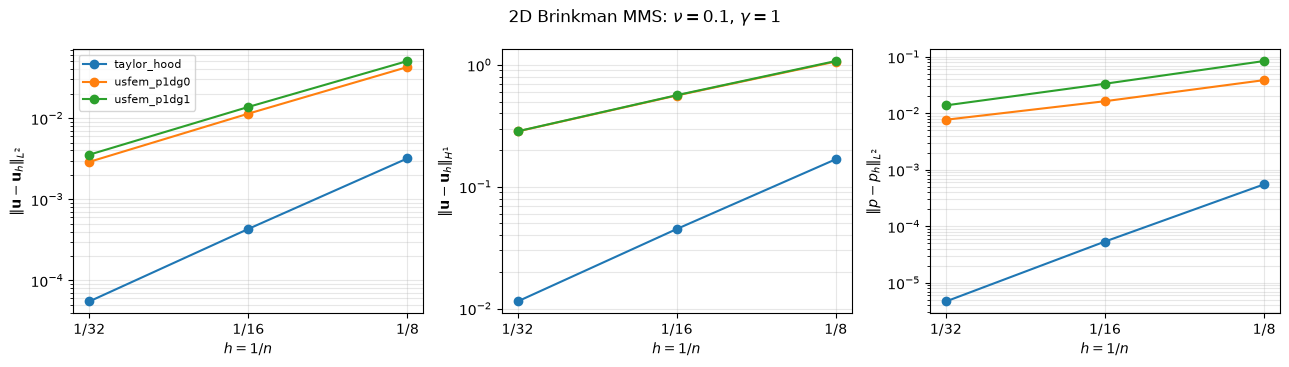

In [5]:
metric_labels = {
    "velocity_l2_error": r"$\|\mathbf{u}-\mathbf{u}_h\|_{L^2}$",
    "velocity_h1_error": r"$\|\mathbf{u}-\mathbf{u}_h\|_{H^1}$",
    "pressure_l2_error": r"$\|p-p_h\|_{L^2}$",
}
figure, axes = plt.subplots(1, 3, figsize=(13, 3.7))
for axis, (metric, label) in zip(axes, metric_labels.items()):
    for method, group in results.groupby("method"):
        axis.loglog(
            group["h"],
            group[metric],
            marker="o",
            label=method,
        )
    tick_values = [1.0 / resolution for resolution in reversed(resolutions)]
    axis.set_xticks(tick_values)
    axis.set_xticklabels([f"1/{resolution}" for resolution in reversed(resolutions)])
    axis.xaxis.set_minor_locator(NullLocator())
    axis.set_xlabel(r"$h=1/n$")
    axis.set_ylabel(label)
    axis.grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)
figure.suptitle(rf"2D Brinkman MMS: $\nu={viscosity:g}$, $\gamma={reaction:g}$")
figure.tight_layout()
display(figure)
plt.close(figure)

## Interpretation and limitations

- Pressure errors are aligned modulo their domain mean because incompressible
  pressure is defined only up to a constant.
- The reported velocity \(H^1\) error is the full norm, not only its
  seminorm.
- Passing this refinement test verifies the implementation for this smooth
  manufactured case. It does not validate heterogeneous coefficients,
  geometry representation, or a particular porous sample.
- At \(\nu=10^{-2}\), a sequence ending at \(64^2\) is still pre-asymptotic
  in velocity; use the reference sequence through \(128^2\).